In [9]:
import os, sys
# Run from project root so all relative paths and imports work
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import yaml
from config import DAS_FILE
from DAS import DAS

with open("configs/denoising.yaml") as f:
    cfg = yaml.safe_load(f)

# Config value takes priority; file metadata used only as fallback
_meta = DAS(DAS_FILE).meta
dx = cfg.get("dx") or _meta["dx"]
dt = cfg.get("dt") or _meta["dt"]

In [12]:
import warnings
warnings.filterwarnings("ignore", message="Pandas requires version", category=UserWarning)

import json
import os
import numpy as np
import pandas as pd
import torch

from models.unet_v2 import UNetV2
from preprocessing import make_preprocess

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

DATA_DIR = cfg.get("data_dir", "data")
SAVE_DIR = cfg.get("save_dir", "results/denoising")
FS_DAS = cfg["fs"]

df = pd.read_csv(os.path.join(DATA_DIR, cfg["labels_csv"]))
df_pos = df[df["count"] > 0].reset_index(drop=True)

with open(os.path.join(SAVE_DIR, "splits.json")) as f:
    splits = json.load(f)

test_df = df_pos[df_pos["sample_id"].isin(splits["test"])].reset_index(drop=True)
print(f"Test set: {len(test_df)} samples")
display(test_df[["sample_id", "count", "vehicle_type"]])

Using device: cuda
Test set: 9 samples


,sample_id,count,vehicle_type
0,1,1,suv
1,2,1,suv
2,10,3,mixed
3,16,2,mixed
4,22,1,truck
5,45,3,mixed
6,48,2,mixed
7,58,3,mixed
8,76,2,mixed


In [13]:
test_df

,count,start_frame,end_frame,vehicle_type,signal_rects,sample_id,data_path
0,1,2022,2173,suv,"[[2060, 2090]]",1,data/raw/sample_000001.npy
1,1,2172,2323,suv,"[[2259, 2289]]",2,data/raw/sample_000002.npy
2,3,3372,3523,mixed,"[[3372, 3389], [3405, 3435], [3410, 3440]]",10,data/raw/sample_000010.npy
3,2,4272,4422,mixed,"[[4272, 4302], [4320, 4350]]",16,data/raw/sample_000016.npy
4,1,5171,5322,truck,"[[5241, 5271]]",22,data/raw/sample_000022.npy
5,3,8620,8771,mixed,"[[8683, 8713], [8692, 8722], [8733, 8763]]",45,data/raw/sample_000045.npy
6,2,9070,9220,mixed,"[[9127, 9157], [9158, 9188]]",48,data/raw/sample_000048.npy
7,3,10569,10720,mixed,"[[10569, 10573], [10648, 10678], [10680, 10710]]",58,data/raw/sample_000058.npy
8,2,13268,13419,mixed,"[[13350, 13380]]",76,data/raw/sample_000076.npy


In [14]:
steps = [(s["name"], {k: v for k, v in s.items() if k != "name"}) for s in cfg["steps"]]
pp = make_preprocess(steps=steps, dx=dx, dt=dt)
print(f"Pipeline steps: {[s[0] for s in steps]}")

Pipeline steps: ['detrend', 'bandpass', 'fk_filter']


In [15]:
model = UNetV2(in_channels=1, out_channels=1).to(device)
print(sum(p.numel() for p in model.parameters()), "parameters")

8311105 parameters


In [16]:
# Load the trained model saved by: python train.py --task denoising
model.load_state_dict(torch.load("results/denoising/best_model.pt", map_location=device))
model.eval()
print("Model loaded from results/denoising/best_model.pt")

Model loaded from results/denoising/best_model.pt


/tmp/ipykernel_385589/3773719988.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("results/denoising/best_model.pt", map_location=device)

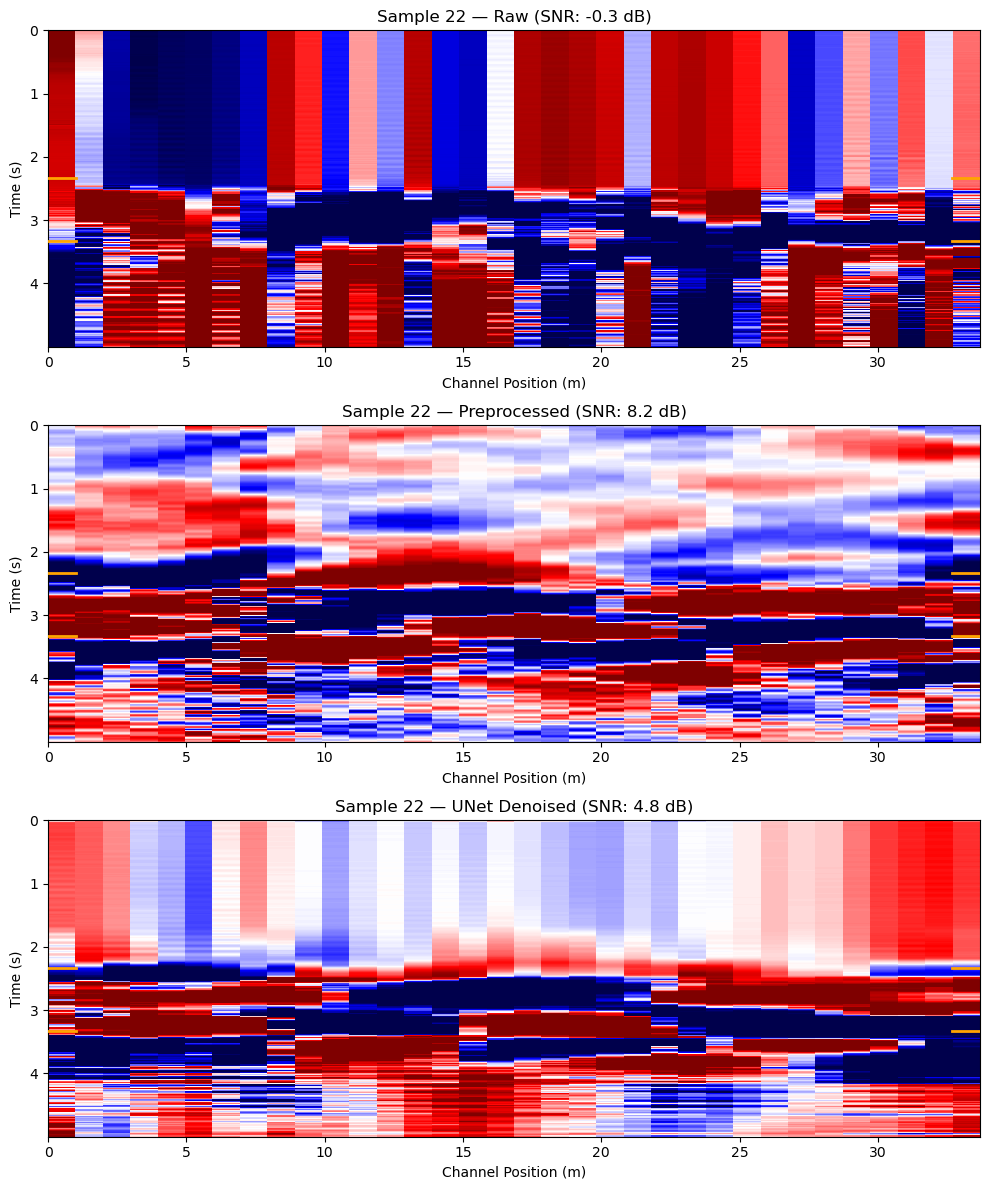

SNR  raw=-0.25 dB | pp=8.17 dB | denoised=4.78 dB


In [20]:
from Utilities import plot_das_data, compute_snr
import matplotlib.pyplot as plt

# Requires labels.csv to have signal_rects column: run `python prepare_data.py` first
SAMPLE_IDX = 4  # change to inspect different test samples

dp_cfg = yaml.safe_load(open("configs/data_prep.yaml"))
fps_video = dp_cfg["fps_video"]

row = test_df.iloc[SAMPLE_IDX]
sid = row["sample_id"]
raw = np.load(row["data_path"]).astype(np.float32)
clean = pp(raw, FS_DAS).astype(np.float32)

# Normalize the same way the dataset does during training
mean, std = raw.mean(), raw.std() + 1e-8
with torch.no_grad():
    raw_norm = (raw - mean) / std
    raw_t = torch.from_numpy(raw_norm[None, None, ...]).to(device)
    pred_norm = model(raw_t).squeeze().cpu().numpy()
pred = pred_norm * std + mean  # restore original signal units

rects = json.loads(row["signal_rects"])
win_start_frame = row["start_frame"]

snr_raw   = compute_snr(raw,   rects, win_start_frame, fps_video, FS_DAS)
snr_clean = compute_snr(clean, rects, win_start_frame, fps_video, FS_DAS)
snr_pred  = compute_snr(pred,  rects, win_start_frame, fps_video, FS_DAS)

channels = np.arange(raw.shape[0])
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
plot_das_data(data=raw,   channels=channels, dx=dx, dt=dt,
              title=f"Sample {sid} — Raw (SNR: {snr_raw:.1f} dB)",
              ax=axes[0], fig=fig, show=False)
plot_das_data(data=clean, channels=channels, dx=dx, dt=dt,
              title=f"Sample {sid} — Preprocessed (SNR: {snr_clean:.1f} dB)",
              ax=axes[1], fig=fig, show=False)
plot_das_data(data=pred,  channels=channels, dx=dx, dt=dt,
              title=f"Sample {sid} — UNet Denoised (SNR: {snr_pred:.1f} dB)",
              ax=axes[2], fig=fig, show=False)

for ax in axes:
    for r_s, r_e in rects:
        t_s = (r_s - win_start_frame) / fps_video
        t_e = (r_e - win_start_frame) / fps_video
        #ax.axhspan(t_s, t_e, alpha=0.2, color="yellow", zorder=2)
        for t in (t_s, t_e):
            ax.axhline(t, xmin=0, xmax=0.03, color="orange", linewidth=2, zorder=3)
            ax.axhline(t, xmin=0.97, xmax=1.0, color="orange", linewidth=2, zorder=3)

plt.tight_layout()
plt.show()
print(f"SNR  raw={snr_raw:.2f} dB | pp={snr_clean:.2f} dB | denoised={snr_pred:.2f} dB")

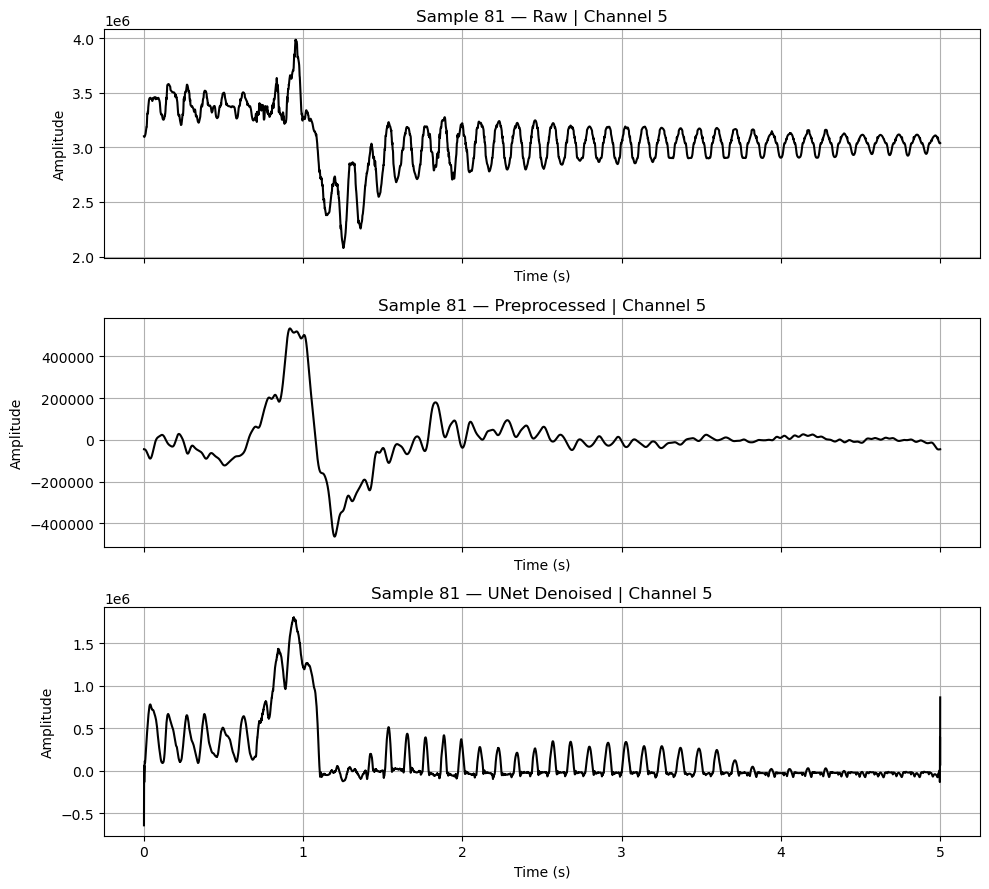

In [10]:
from Utilities import plot_single
import matplotlib.pyplot as plt

CHANNEL = 5  # channel to inspect
T0, T1 = 0, 5

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

plot_single(data=raw,   channel_num=CHANNEL, dx=dx, dt=dt, start_time=T0, end_time=T1, ax=axes[0], show=False)
axes[0].set_title(f"Sample {sid} — Raw | Channel {CHANNEL}")

plot_single(data=clean, channel_num=CHANNEL, dx=dx, dt=dt, start_time=T0, end_time=T1, ax=axes[1], show=False)
axes[1].set_title(f"Sample {sid} — Preprocessed | Channel {CHANNEL}")

plot_single(data=pred,  channel_num=CHANNEL, dx=dx, dt=dt, start_time=T0, end_time=T1, ax=axes[2], show=False)
axes[2].set_title(f"Sample {sid} — UNet Denoised | Channel {CHANNEL}")

plt.tight_layout()
plt.show()

In [ ]:
# Run `python predict.py --task denoising` to regenerate data/denoised/
print("Denoised samples → data/denoised/  |  Run: python predict.py --task denoising")